In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("LULC.xlsx")

In [3]:
df["Class"].unique()

array(["Terres arables hors périmètres d'irrigation",
       'Tissu urbain discontinu',
       'Prairies et autres surfaces toujours en herbe à usage agricole',
       'Forêts de feuillus',
       'Systèmes culturaux et parcellaires complexes',
       'Surfaces essentiellement agricoles, interrompues par des espaces naturels importants',
       'Zones industrielles ou commerciales et installations publiques',
       'Forêt et végétation arbustive en mutation', 'Forêts de conifères',
       'Equipements sportifs et de loisirs'], dtype=object)

In [4]:
categories = {
    "Equipements sportifs et de loisirs": "Loisirs",
    "Forêt et végétation arbustive en mutation": "Forêt",
    "Forêts de conifères": "Forêt",
    "Forêts de feuillus": "Forêt",
    "Prairies et autres surfaces toujours en herbe naturelles": "Agriculture",
    "Surfaces essentiellement agricoles, interrompues par des structures naturelles": "Agriculture",
    "Systèmes culturaux et parcellaires complexes": "Agriculture",
    "Terres arables hors périmètres d'irrigation": "Agriculture",
    "Tissu urbain discontinu": "Urbain",
    "Zones industrielles ou commerciales et installations publiques": "Industrie",
    "Prairies et autres surfaces toujours en herbe à usage agricole": "Agriculture",
    "Surfaces essentiellement agricoles, interrompues par des espaces naturels importants": "Agriculture"
}

df["categories"] = df["Class"].map(categories).fillna("Autres")

df_categorized = df.groupby("categories")["Surface"].sum().reset_index().round(1)


df_categorized["Pourcentage"] = ((df_categorized["Surface"] / 460) * 100).round(1)

df_categorized

,categories,Surface,Pourcentage
0,Agriculture,353.2,76.8
1,Forêt,69.0,15.0
2,Industrie,3.8,0.8
3,Loisirs,0.3,0.1
4,Urbain,33.2,7.2


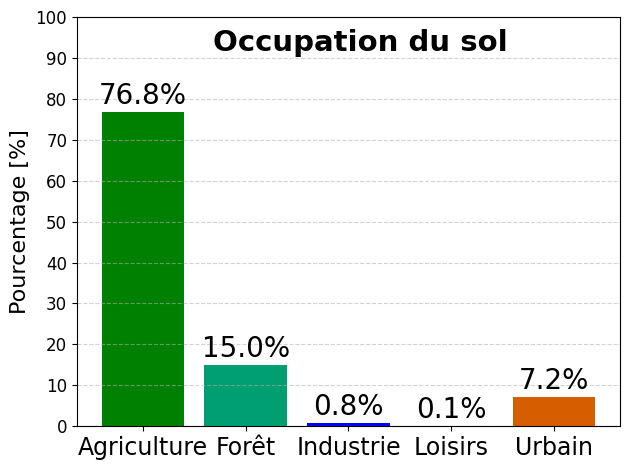

In [ ]:
bars = plt.bar(df_categorized["categories"], df_categorized["Pourcentage"], color=["green", "#009E73", "blue", "red", "#D55E00"])
plt.ylabel("Pourcentage [%]", fontsize=16)
plt.yticks(fontsize=12)
plt.xticks(fontsize=17)
plt.grid(axis="y", linestyle="--", alpha=0.55)
plt.yticks(np.arange(0, 101, 10))
plt.text(0.25, 0.97, "Occupation du sol", transform=plt.gca().transAxes, fontsize=21, fontweight="bold", color="#000000", ha="left", va="top")


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{height:.1f}%", ha='center', va='bottom', fontsize=20)


plt.tight_layout()